# Movie Dataset Analysis
## Questions I want to answer
1. Which genres are the most common?
2. Do higher-budget movies get higher revenues?
3. How have average budgets changed over the years?
4. Which movies are the highest profitable?

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os

path = kagglehub.dataset_download("abdallahwagih/movies")
df = pd.read_csv(path + '/movies.csv')
df.head()

df['release_date'] = pd.to_datetime(df['release_date'])
df['year'] = df['release_date'].dt.year

Using Colab cache for faster access to the 'movies' dataset.


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

,index,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4803.000000,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2401.000000,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,1386.651002,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,1200.500000,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,2401.000000,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,3601.500000,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,4802.000000,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


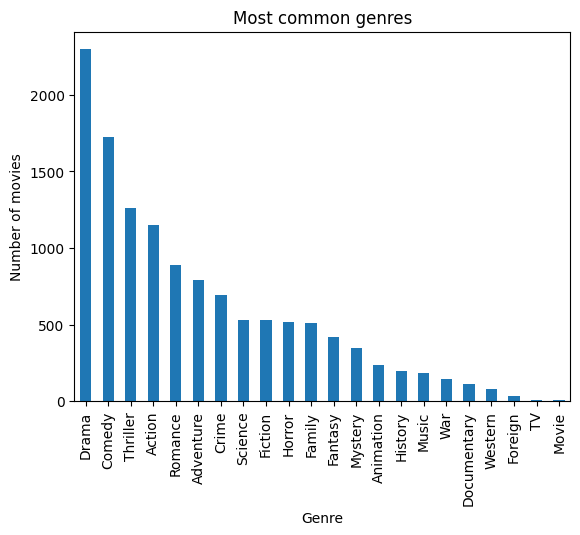

In [6]:
df['genres'].str.split(' ').explode().value_counts().plot(kind='bar')
plt.title("Most common genres")
plt.xlabel("Genre")
plt.ylabel('Number of movies')
plt.show()

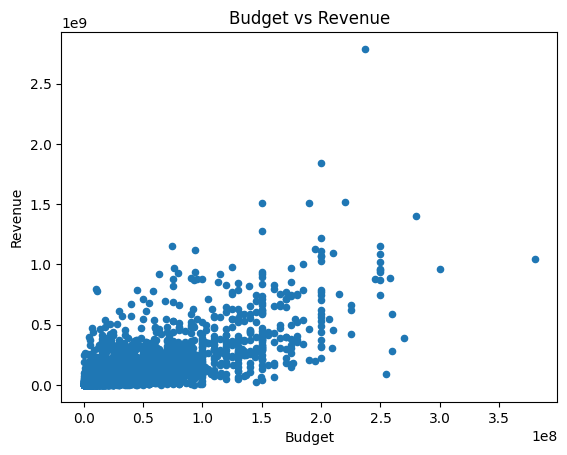

In [7]:
clean = df[(df['budget'] > 0) & (df['revenue'] > 0)]
clean.plot.scatter(x='budget', y='revenue')
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()

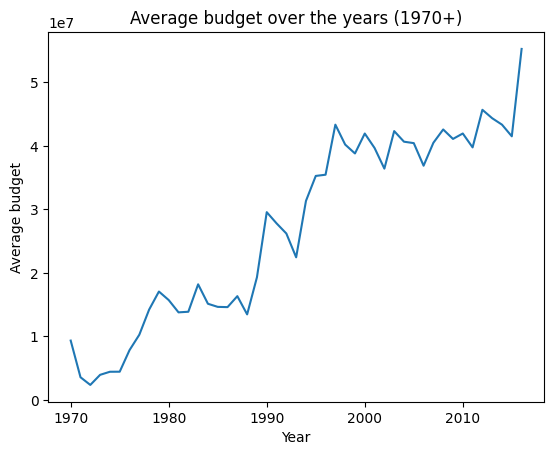

In [13]:
clean = df[(df['budget'] > 0) & (df['year'] >= 1970)]
clean.groupby('year')['budget'].mean().plot()
plt.title("Average budget over the years (1970+)")
plt.xlabel("Year")
plt.ylabel("Average budget")
plt.show()